Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
       open      high       low     close        volume merge_date
0  93347.59  94960.91  92743.63  94383.59   6871.738482 2025-01-01
1  94383.59  97776.99  94177.00  96903.19  10912.473840 2025-01-02
2  96905.48  98969.92  96016.63  98136.51   9021.885382 2025-01-03
3  98139.85  98761.02  97516.65  98209.85   2742.089606 2025-01-04
4  98209.85  98814.00  97250.00  98345.33   2377.921759 2025-01-05
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=4522.751, Time=0.13 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=4514.701, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=4516.679, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=4516.652, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=4512.921, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=4518.623, Time=0.06 sec

Best model:  ARIMA(0,1,0)(0,0

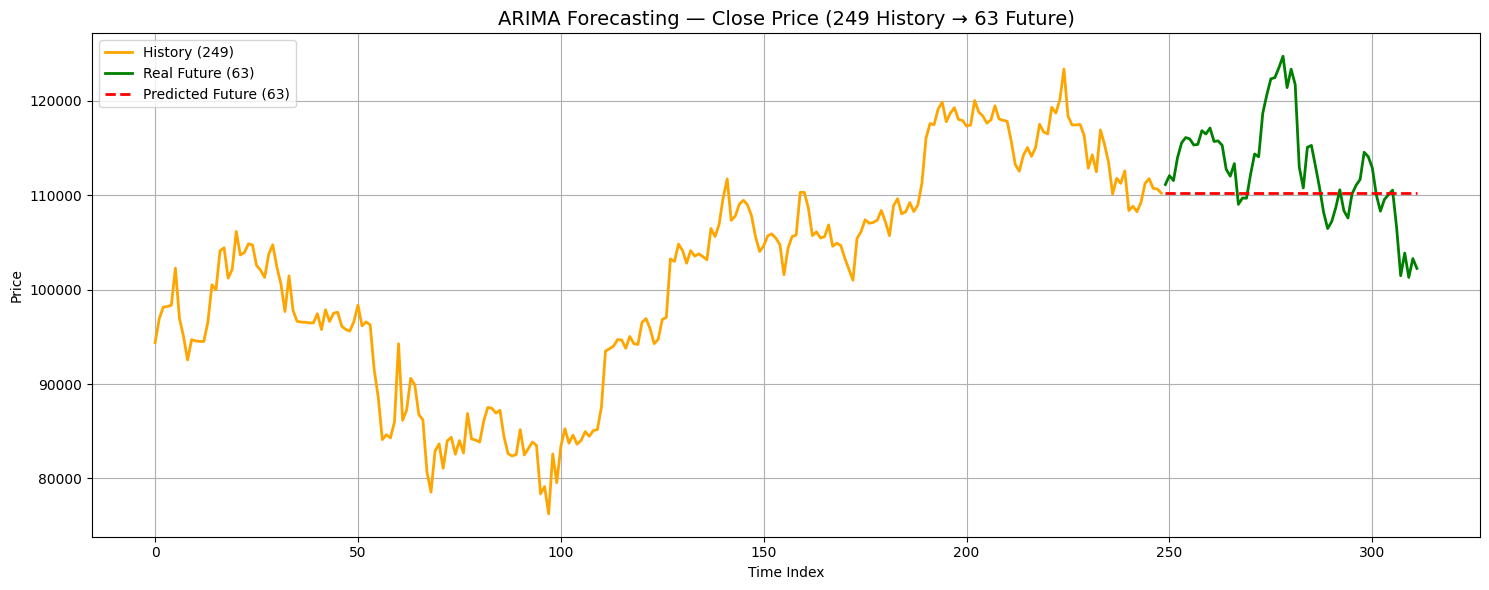

In [2]:
# -*- coding: utf-8 -*-
# ================================
#        ARIMA Forecasting
#        HISTORY = 249, FORECAST = 63
# ================================

!pip install -q pmdarima

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima

# -----------------------------
# 1) خواندن دیتای واقعی
# -----------------------------
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv(
    '/content/drive/MyDrive/data/FINAL SELECTED DATA SET/Bitcoin.csv',
    sep=';',
    parse_dates=['merge_date'],
    dayfirst=True
)

print(df.head())

# -----------------------------
# 2) انتخاب سری زمانی close
# -----------------------------
series = df['close'].astype(float).values
HISTORY = 249
FORECAST = 63

# سری history = 249
history_series = series[:HISTORY]

# سری واقعی آینده = 63
real_future = series[HISTORY:HISTORY+FORECAST]

# -----------------------------
# 3) ساخت مدل ARIMA روی 249 مقدار تاریخچه
# -----------------------------
model = auto_arima(
    history_series,
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print("\nModel summary:")
print(model.summary())

# -----------------------------
# 4) پیش‌بینی 63 گام آینده
# -----------------------------
forecast = model.predict(n_periods=FORECAST)

# -----------------------------
# 5) رسم نمودار تمیز و پیوسته
# -----------------------------
plt.figure(figsize=(15,6))

# 1) تاریخچه واقعی
plt.plot(np.arange(HISTORY), history_series, label='History (249)', linewidth=2, color='orange')

# 2) آینده واقعی (63 مقدار)
plt.plot(np.arange(HISTORY, HISTORY+FORECAST), real_future, label='Real Future (63)', linewidth=2, color='green')

# 3) آینده پیش‌بینی شده ARIMA
plt.plot(np.arange(HISTORY, HISTORY+FORECAST), forecast, '--', label='Predicted Future (63)', linewidth=2, color='red')

plt.title("ARIMA Forecasting — Close Price (249 History → 63 Future)", fontsize=14)
plt.xlabel("Time Index")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
